# Verifying the SAV model's published results

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sear-labs/sav-osemosys-trd-2019/blob/main/notebooks/00_verify.ipynb)

The optimisation model behind **Jones and Leibowicz (2019)**, *Transportation Research
Part D*, [10.1016/j.trd.2019.05.005](https://doi.org/10.1016/j.trd.2019.05.005).

**Nothing here solves anything.** No solver, no licence, no Gurobi — this notebook
*checks* results rather than reproducing them, which is a different and in some ways
stronger thing: re-solving asks you to trust a solver, a licence and a machine, while
checking asks you to trust arithmetic.

Three things are established below:

1. the ten published scenarios, and how they compare to the two figures the paper prints
2. the shipped reduced instance, verified row by row and bound by bound
3. what does **not** reproduce, and why that is a property of the model rather than a defect

In [1]:
# Works from a clone or from Colab with nothing checked out.
try:
    import sav_osemosys  # noqa: F401
except ImportError:
    !pip install -q "git+https://github.com/sear-labs/sav-osemosys-trd-2019.git"

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

## 1. The published results

`results/clean/` is tidy long-format output — one value per row, named columns. The raw
GAMS report is wide and ragged, with a *varying* number of index columns; assuming a
fixed number once dropped 19% of a comparison silently. Nothing downstream reads it.

In [2]:
from sav_osemosys.figures import load_clean

annual = load_clean("annual")
objective = load_clean("objective")
timeslice = load_clean("timeslice")

print(f"annual     {len(annual):>8,} rows")
print(f"timeslice  {len(timeslice):>8,} rows")
print(f"objective  {len(objective):>8,} rows")
annual.head()

annual       65,880 rows
timeslice   151,200 rows
objective        10 rows


,scenario,quantity,region,technology,item,year,value
0,1,TotalAnnualCapacity,ATX,COALPP,NaN,2015,0.73
1,1,TotalAnnualCapacity,ATX,COALPP,NaN,2016,0.71
2,1,TotalAnnualCapacity,ATX,COALPP,NaN,2017,0.69
3,1,TotalAnnualCapacity,ATX,COALPP,NaN,2018,0.66
4,1,TotalAnnualCapacity,ATX,COALPP,NaN,2019,0.64


### The Table 2 grid, as run

The paper crosses SAV diffusion, carbon tax, charging paradigm and a travel-demand
multiplier. The 2018 run file that survived produces **two** solves under an emissions
*cap*; the paper runs **ten** under a *tax*. That mismatch is why the paper resisted
reproduction for years.

In [3]:
import io, urllib.request

def read_grid():
    """Local first, then the copy on GitHub — same rule the package uses for data."""
    local = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / "scenarios" / "table2.csv").is_file()), None)
    if local:
        text = (local / "scenarios" / "table2.csv").read_text()
    else:
        text = urllib.request.urlopen(f"{RAW_BASE}/scenarios/table2.csv").read().decode()
    return pd.read_csv(io.StringIO("\n".join(l for l in text.splitlines()
                                              if not l.startswith("#"))))

from pathlib import Path
RAW_BASE = "https://raw.githubusercontent.com/sear-labs/sav-osemosys-trd-2019/main"
grid = read_grid()
table = grid.merge(objective, on="scenario")
table

,scenario,sav,tax,charging,dm,objective
0,1,70,no,optimized,0.5,66113.20
1,2,70,no,optimized,2.0,85409.64
2,3,70,no,optimized,1.0,72412.33
3,4,70,no,night,1.0,75110.56
4,5,none,no,NaN,NaN,92091.39
5,6,70,yes,optimized,0.5,71267.76
6,7,70,yes,optimized,2.0,90819.95
7,8,70,yes,optimized,1.0,77638.36
8,9,70,yes,night,1.0,80451.63
9,10,none,yes,NaN,NaN,97883.08


### The acceptance test

The paper prints **no cost figures at all** — Fig. 10 gives objective values as bar
heights with no table — so not one number in the objective column can be checked against
the article. The electricity mix is the only published quantity this model can be held
to, and the paper states two figures:

- without a carbon tax, natural gas is **80%** of electricity produced in 2035
- with one, gas **peaks at 56%**, in **2021**

The denominator is generation only: storage, V2G and charging also produce electricity
but move it rather than make it.

In [4]:
from sav_osemosys.figures import gas_share

rows = []
for _, r in grid.iterrows():
    s = gas_share(annual, r.scenario)
    rows.append({"scenario": r.scenario, "sav": r.sav, "tax": r.tax,
                 "charging": r.charging, "dm": r.dm,
                 "gas 2035 %": round(s.loc[2035], 1),
                 "peak %": round(s.max(), 1), "peak year": s.idxmax()})
summary = pd.DataFrame(rows)
summary

,scenario,sav,tax,charging,dm,gas 2035 %,peak %,peak year
0,1,70,no,optimized,0.5,80.6,80.6,2035
1,2,70,no,optimized,2.0,77.7,78.0,2036
2,3,70,no,optimized,1.0,79.6,79.6,2035
3,4,70,no,night,1.0,80.0,80.0,2035
4,5,none,no,NaN,NaN,80.5,80.5,2035
5,6,70,yes,optimized,0.5,14.2,55.7,2021
6,7,70,yes,optimized,2.0,13.7,56.9,2021
7,8,70,yes,optimized,1.0,14.0,55.6,2021
8,9,70,yes,night,1.0,13.6,55.9,2021
9,10,none,yes,NaN,NaN,14.3,55.7,2021


In [5]:
no_tax = summary[(summary.tax == "no") & (summary.sav == "70")]
taxed = summary[(summary.tax == "yes") & (summary.sav == "70")]

print("no tax  — paper says gas is 80% of generation in 2035")
for _, r in no_tax.iterrows():
    print(f"   scenario {r.scenario:>2}: {r['gas 2035 %']:>5.1f}%   off by {r['gas 2035 %']-80:+.1f}")
print()
print("tax     — paper says gas peaks at 56%, in 2021")
for _, r in taxed.iterrows():
    print(f"   scenario {r.scenario:>2}: {r['peak %']:>5.1f}% in {r['peak year']}"
          f"   off by {r['peak %']-56:+.1f}, {r['peak year']-2021:+d} yr")
print()
print(f"every taxed scenario peaks in {sorted(set(taxed['peak year']))} "
      f"— the paper's year, and it does not move with the demand multiplier")

no tax  — paper says gas is 80% of generation in 2035
   scenario  1:  80.6%   off by +0.6
   scenario  2:  77.7%   off by -2.3
   scenario  3:  79.6%   off by -0.4
   scenario  4:  80.0%   off by +0.0

tax     — paper says gas peaks at 56%, in 2021
   scenario  6:  55.7% in 2021   off by -0.3, +0 yr
   scenario  7:  56.9% in 2021   off by +0.9, +0 yr
   scenario  8:  55.6% in 2021   off by -0.4, +0 yr
   scenario  9:  55.9% in 2021   off by -0.1, +0 yr

every taxed scenario peaks in [2021] — the paper's year, and it does not move with the demand multiplier


**The peak year is the load-bearing evidence.** The old emissions-cap run peaks at 54.6%
in **2025** — right magnitude, four years late, which is exactly what a cap ramping
linearly to 2050 does against a tax that bites immediately. Enabling the tax moves the
peak to 2021 and it stays there across every taxed case regardless of demand multiplier
or charging paradigm. That is a signature, not a coincidence.

## 2. Figures

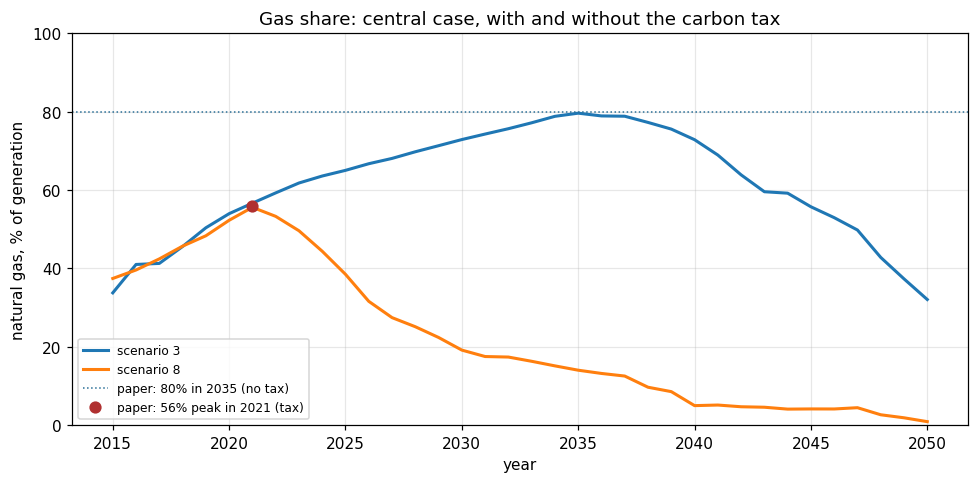

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
from sav_osemosys.figures import plot_gas_share
plot_gas_share(annual, [3, 8], ax=ax)
ax.set_title("Gas share: central case, with and without the carbon tax")
plt.tight_layout(); plt.show()

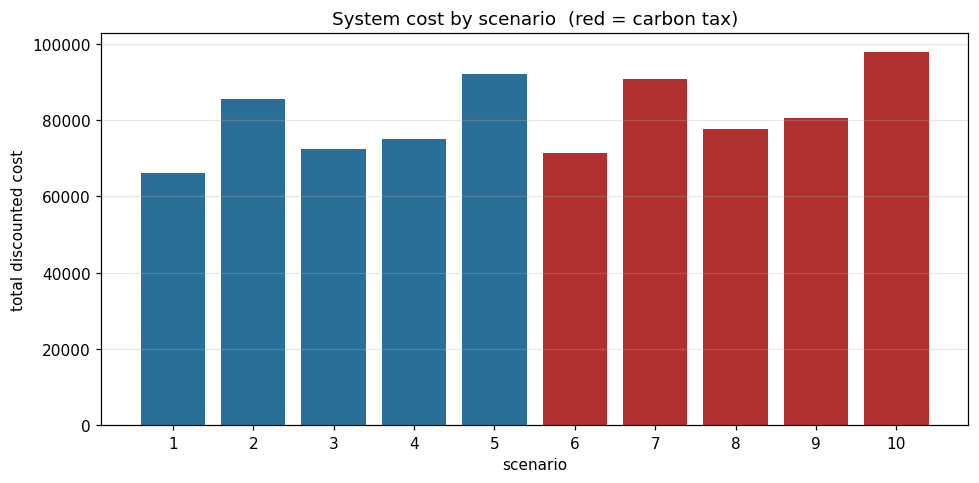

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
from sav_osemosys.figures import plot_objectives
plot_objectives(objective, ax=ax, grid=grid)
plt.tight_layout(); plt.show()

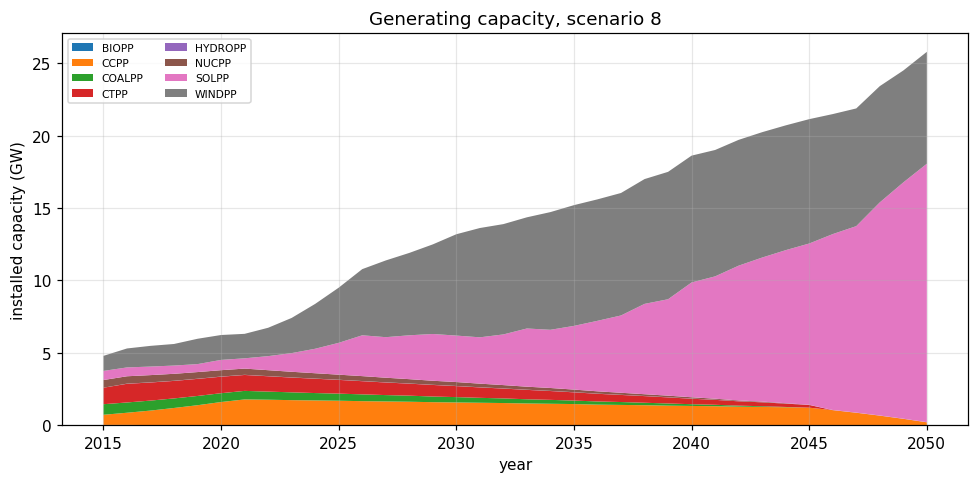

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
from sav_osemosys.figures import plot_capacity_mix
plot_capacity_mix(annual, 8, ax=ax)
plt.tight_layout(); plt.show()

## 3. Checking a solution by hand — no solver

The repository ships a **reduced instance** as standard `.mps` and `.sol` files. The cell
below reads both and verifies every constraint row, every variable bound, and the
objective, using numpy and nothing else.

The *full* model cannot be shipped this way: its `.mps` is about **3.4 GB** against
GitHub's 100 MB limit, measured. That is a real limit of this pattern and worth stating
rather than working around quietly.

In [9]:
import urllib.request, tempfile
from pathlib import Path
from sav_osemosys.verify import check_instance

def fetch(relative):
    local = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / relative).is_file()), None)
    if local:
        return local / relative
    target = Path(tempfile.gettempdir()) / Path(relative).name
    if not target.exists():
        urllib.request.urlretrieve(f"{RAW_BASE}/{relative}", target)
    return target

mps = fetch("artifacts/reduced-scenario-03.mps.gz")
sol = fetch("artifacts/reduced-scenario-03.sol.gz")

result = check_instance(mps, sol)
print(result.summary())
print()
print("verdict:", "PASS" if result.ok() else "FAIL")

  rows checked            72,877
  bounds checked          70,355
  worst row violation     5.024e-12  (4.651e-18 relative)   [EBa3_RateOfFuelProduction3[2015,W13,VMT]]
  worst bound violation   0.000e+00   [-]
  objective in .sol       5900.422796830308
  objective recomputed    5900.422797

verdict: PASS


Violations are measured **relative to the largest coefficient in the problem**. An
absolute threshold is the wrong instrument here — this model's matrix spans twelve orders
of magnitude, so a fixed tolerance either waves everything through or rejects correct
answers.

## 4. What does not reproduce

Cost and totals reproduce. **Dispatch and build timing do not, and never were unique.**
This is a degenerate LP: storage charge and discharge shift between timeslices at zero
cost, so many different schedules achieve the same optimal cost.

The surviving differences against the 2018 reference are of exactly two kinds:

- **under 0.005 absolute** — the GAMS report writer prints two decimals, so this is the
  print format rather than the model.
- **`EV_DISCHARGE` and `EV_DISCHARGE_F`**, differing by 9–22%. Nothing constrains their
  capacity and nothing charges for it, so the optimum does not determine them at all.

That is the whole residual. It is written down because an unexplained residual is
indistinguishable from an unfound bug.

**So: do not cite a specific build year or storage level from this model.** Cost, capacity
totals and emissions are reproducible; the schedule is one optimal answer among many.